# 手寫阿拉伯數字辨識 專家模式

## 載入套件

In [ ]:
import sys
from pathlib import Path
from typing import cast, Sized

import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.transform import resize
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

## 設定參數

In [ ]:
# 設定參數
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 1024  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'cpu'

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [3]:
# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transforms.ToTensor())

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transforms.ToTensor())

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 步驟2：資料清理，此步驟無需進行

## 步驟3：特徵工程，此步驟無需進行

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 步驟5：建立模型結構

In [4]:
# 建立模型
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)  # 完全連接層
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 10)  # 完全連接層

    def forward(self, x: torch.Tensor):
        # 完全連接層 + dropout + 完全連接層 + dropout + log_softmax
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        return x


# 建立模型物件
model = Net().to(device)

## 設定模型及學習率組態

## 步驟6：結合訓練資料及模型，進行模型訓練

In [5]:
epochs = 5
lr = 0.1

# 建立 DataLoader
train_loader = DataLoader(train_ds, batch_size=600)

# 設定優化器(optimizer)
optimizer = optim.Adam(model.parameters(), lr=lr)

# 設定損失函數(loss)
criterion = nn.CrossEntropyLoss()

model.train()
loss_list = []
for epoch in range(1, epochs + 1):
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        # 計算損失(loss)
        loss = criterion.forward(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            loss_list.append(loss.item())
            batch = (batch_idx + 10) * len(data)
            data_count = len(train_ds)
            percentage = 100.0 * batch / len(cast(Sized, train_loader.dataset))
            print(f'Epoch {epoch}: [{batch:5d} / {data_count}] ({percentage:.0f} %)  Loss: {loss.item():.6f}')

Epoch 1: [ 6000 / 60000] (10 %)  Loss: 2.290592
Epoch 1: [12000 / 60000] (20 %)  Loss: 40.444149
Epoch 1: [18000 / 60000] (30 %)  Loss: 22.251888
Epoch 1: [24000 / 60000] (40 %)  Loss: 8.086437
Epoch 1: [30000 / 60000] (50 %)  Loss: 10.249131
Epoch 1: [36000 / 60000] (60 %)  Loss: 6.125251
Epoch 1: [42000 / 60000] (70 %)  Loss: 4.105983
Epoch 1: [48000 / 60000] (80 %)  Loss: 4.802993
Epoch 1: [54000 / 60000] (90 %)  Loss: 2.546615
Epoch 1: [60000 / 60000] (100 %)  Loss: 4.510021
Epoch 2: [ 6000 / 60000] (10 %)  Loss: 1.987844
Epoch 2: [12000 / 60000] (20 %)  Loss: 1.191664
Epoch 2: [18000 / 60000] (30 %)  Loss: 2.978667
Epoch 2: [24000 / 60000] (40 %)  Loss: 2.316502
Epoch 2: [30000 / 60000] (50 %)  Loss: 2.276459
Epoch 2: [36000 / 60000] (60 %)  Loss: 2.290147
Epoch 2: [42000 / 60000] (70 %)  Loss: 1.867596
Epoch 2: [48000 / 60000] (80 %)  Loss: 1.934742
Epoch 2: [54000 / 60000] (90 %)  Loss: 0.852159
Epoch 2: [60000 / 60000] (100 %)  Loss: 1.498458
Epoch 3: [ 6000 / 60000] (10 %)  Lo

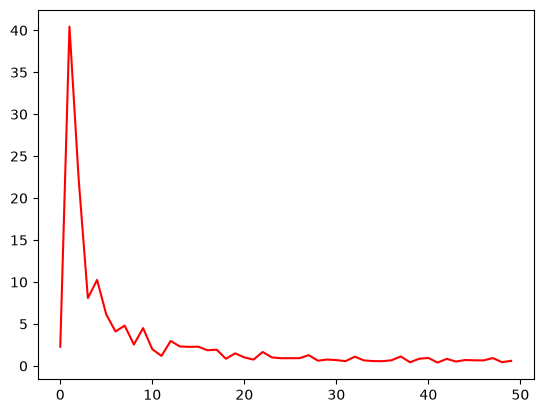

In [6]:
# 對訓練過程的損失繪圖
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [7]:
# 建立 DataLoader
test_loader = DataLoader(test_ds, batch_size=600)

model.eval()
test_loss = 0
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output: torch.Tensor = model(data)

        # sum up batch loss
        test_loss += criterion.forward(output, target).item()

        # 預測
        pred = output.argmax(dim=1, keepdim=True)

        # 正確筆數
        correct += pred.eq(target.view_as(pred)).sum().item()

data_count = len(cast(Sized, test_loader.dataset))
# 平均損失
test_loss /= data_count
# 顯示測試結果
percentage = 100.0 * correct / data_count
print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

平均損失: 0.0015, 準確率: 8626/10000 (86%)



In [8]:
# 實際預測 20 筆資料
predictions = []
with torch.no_grad():
    for i in range(20):
        data: torch.Tensor = test_ds[i][0]
        data = data.reshape(1, *data.shape).to(device)
        output = torch.argmax(model(data), dim=-1)
        predictions.append(str(output.item()))

# 比對
print('actual    :', test_ds.targets[0:20].numpy())
print('prediction: ', ' '.join(predictions[0:20]))

actual    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
prediction:  7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4


## 步驟8：評估，暫不進行

## 步驟9：模型佈署

## 步驟10：新資料預測

In [ ]:
# 使用小畫家，繪製 0~9，實際測試看看
# 讀取影像並轉為單色
for i in range(10):
    uploaded_file = base_path / f'myDigits/{i}.png'
    image1 = io.imread(uploaded_file, as_gray=True)

    # 縮為 (28, 28) 大小的影像
    image_resized = resize(image1, (28, 28), anti_aliasing=True)    
    X1 = np.asarray(image_resized).reshape(1, 28, 28)  # / 255.0

    # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
    X1 = torch.FloatTensor(1-X1).to(device)

    # 預測
    predictions = torch.softmax(model(X1), dim=1)
    # print(np.around(predictions.cpu().detach().numpy(), 2))
    print(f'actual/prediction: {i} {np.argmax(predictions.detach().cpu().numpy())}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 5
actual/prediction: 3 7
actual/prediction: 4 7
actual/prediction: 5 5
actual/prediction: 6 6
actual/prediction: 7 7
actual/prediction: 8 8
actual/prediction: 9 8
